- imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

- Load data

In [4]:
df=pd.read_csv("C:/Users/shiva/Downloads/drowsiness.csv")

In [5]:
plt.style.use('seaborn-v0_8-pastel')
sns.set_palette("muted")

# phase 1 (Data reading and UNderstanding)

In [6]:
df.shape

(10000, 11)

In [7]:
df.sample(6)

,Age,Gender,Blink_Rate,Eye_Closure_Duration,Yawning_Count,Heart_Rate,Head_Tilt_Angle,Steering_Variation,Reaction_Time,Sleep_Hours_Last_Night,Drowsy
8907,48,Female,25,53.795822,7,67.0,0.067211,0.689886,NaN,5.594911,0
8299,57,Male,14,14.810625,2,62.0,15.842386,1.280546,1.947084,8.542567,0
2082,25,F,21,59.705982,2,90.0,11.504832,0.216920,NaN,7.380516,0
9857,35,Male,34,52.449027,0,81.0,14.467148,1.029321,1.750070,3.535920,0
2320,56,Male,38,40.513163,6,65.0,11.692361,1.379700,0.444025,5.777144,0
4957,25,F,37,49.681738,7,73.0,4.634640,1.481068,0.576343,7.132104,0


In [8]:
# we can see by the sample that there are some inconsistent values in the gender column
df['Gender'].unique()

array(['M', 'Male', 'F', 'Female'], dtype=object)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     10000 non-null  int64  
 1   Gender                  10000 non-null  object 
 2   Blink_Rate              10000 non-null  int64  
 3   Eye_Closure_Duration    9500 non-null   float64
 4   Yawning_Count           10000 non-null  int64  
 5   Heart_Rate              9500 non-null   float64
 6   Head_Tilt_Angle         10000 non-null  float64
 7   Steering_Variation      10000 non-null  float64
 8   Reaction_Time           9500 non-null   float64
 9   Sleep_Hours_Last_Night  10000 non-null  float64
 10  Drowsy                  10000 non-null  int64  
dtypes: float64(6), int64(4), object(1)
memory usage: 859.5+ KB


In [10]:
df.describe()

,Age,Blink_Rate,Eye_Closure_Duration,Yawning_Count,Heart_Rate,Head_Tilt_Angle,Steering_Variation,Reaction_Time,Sleep_Hours_Last_Night,Drowsy
count,10000.000000,10000.000000,9500.000000,10000.000000,9500.000000,10000.000000,10000.000000,9500.000000,10000.000000,10000.000000
mean,41.054000,25.381300,32.899217,3.522500,84.470316,12.582987,0.806366,1.104985,5.482929,0.197500
std,13.484104,11.595997,15.837722,2.290288,14.403275,7.238207,0.403856,0.521325,2.036146,0.398133
min,18.000000,10.000000,5.002647,0.000000,60.000000,0.002332,0.100181,0.200086,2.001022,0.000000
25%,30.000000,17.000000,19.311759,2.000000,72.000000,6.315103,0.459187,0.654667,3.721904,0.000000
50%,41.000000,25.000000,33.001419,4.000000,85.000000,12.605863,0.806115,1.099336,5.451221,0.000000
75%,53.000000,32.000000,46.447697,6.000000,97.000000,18.885967,1.160959,1.564195,7.261158,0.000000
max,64.000000,117.000000,59.994554,7.000000,109.000000,24.995224,1.499806,1.999811,8.999250,1.000000


In [11]:
''' 
In the above data we can see that there are total of 10 independent features and one target 
1. Age: 18-64 with average age around 41.
2. Blink_rate : no of blink/min , as we can see there are some extreme outlier values.
3. Eye_Closure_Duration: in ms , mean value ~33.
4. Yawning count: 0-7 ,average ~3.5.
5. heart rate: beats per minute(bpm), range 60-109 .
6. head tilt angle : mean ~12.5 .
7. Streering variation : mean ~0.8 .
8. reaction time: mean ~1.1.
9. sleep hour last night: in hours, average ~5.5.
10.drowsy : high class imbalance can be observed.
'''

' \nIn the above data we can see that there are total of 10 independent features and one target \n1. Age: 18-64 with average age around 41.\n2. Blink_rate : no of blink/min , as we can see there are some extreme outlier values.\n3. Eye_Closure_Duration: in ms , mean value ~33.\n4. Yawning count: 0-7 ,average ~3.5.\n5. heart rate: beats per minute(bpm), range 60-109 .\n6. head tilt angle : mean ~12.5 .\n7. Streering variation : mean ~0.8 .\n8. reaction time: mean ~1.1.\n9. sleep hour last night: in hours, average ~5.5.\n10.drowsy : high class imbalance can be observed.\n'

In [12]:
'''
- sensory generated features-[blink_rate,Eye_Closure_Duration, 
           Yawning_Count, Heart_Rate, Head_Tilt_Angle, Steering_Variation, Reaction_Time.]
- user provided feature-[Age, Gender, Sleep_Hours_Last_Night.]

This distinction matters because sensor features are  prone to 
noise/outliers/sensor failure, and must be handled for real-time 
inference, while user-provided features  may contain entry errors, 
and are better suited for simple encoding or validation rules.
'''

'\n- sensory generated features-[blink_rate,Eye_Closure_Duration, \n           Yawning_Count, Heart_Rate, Head_Tilt_Angle, Steering_Variation, Reaction_Time.]\n- user provided feature-[Age, Gender, Sleep_Hours_Last_Night.]\n\nThis distinction matters because sensor features are  prone to \nnoise/outliers/sensor failure, and must be handled for real-time \ninference, while user-provided features  may contain entry errors, \nand are better suited for simple encoding or validation rules.\n'

In [13]:
'''As we know if a person is feeling drowsy that can cause a crash so in the dataset 
if our danger flag(ie. drowsy ) is 0 it means the driver is aleart and safe to drive 
but if the system says 1 then we need to warn the driver about the potential risk '''

'As we know if a person is feeling drowsy that can cause a crash so in the dataset \nif our danger flag(ie. drowsy ) is 0 it means the driver is aleart and safe to drive \nbut if the system says 1 then we need to warn the driver about the potential risk '

In [14]:
'''As in our dataset we have max blink rate of 108 . and the possible blink rate of 
humans is typically 10-20 blinks per minute . which shows that these values are physically impossible.
'''

'As in our dataset we have max blink rate of 108 . and the possible blink rate of \nhumans is typically 10-20 blinks per minute . which shows that these values are physically impossible.\n'

# Phase 2 (Data Cleaning)

- missing values

In [15]:
df.isnull().sum()

Age                         0
Gender                      0
Blink_Rate                  0
Eye_Closure_Duration      500
Yawning_Count               0
Heart_Rate                500
Head_Tilt_Angle             0
Steering_Variation          0
Reaction_Time             500
Sleep_Hours_Last_Night      0
Drowsy                      0
dtype: int64

In [16]:
df[df['Reaction_Time'].isnull()]['Drowsy'].value_counts()

Drowsy
0    402
1     98
Name: count, dtype: int64

In [17]:
# there are many missing values in important feature like reaction time,heart rate and eye closure duration 
# these can be filled by using knnimputer which will fill value accordingly by following the pattern of neighbours

- gender inconsistency

In [18]:
df['Gender'].value_counts()

Gender
F         2535
Male      2525
M         2477
Female    2463
Name: count, dtype: int64

In [19]:
def clean_gender(g):
    g = str(g).strip().lower()
    if g in ['m', 'male']:
        return 'Male'
    if g in ['f', 'female']:
        return 'Female'
    return 'Unknown'  # catch future weird values

df['Gender'] = df['Gender'].apply(clean_gender)

- blink rate outliers

Blink_Rate description before treatment:


<Axes: xlabel='Blink_Rate', ylabel='Count'>

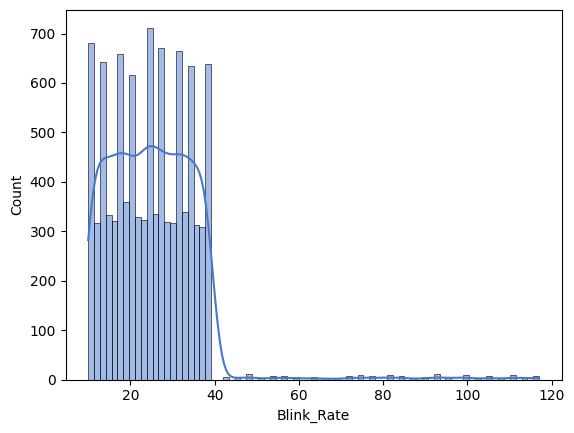

In [20]:
print("Blink_Rate description before treatment:")
sns.histplot(df['Blink_Rate'],kde=True)
# as we can see that most of the values lie below 40 so we will cap them as removing them can lead to a loss of important data

In [21]:
df['Blink_Rate'] = df['Blink_Rate'].clip(
    lower=0,
    upper=41
)

Blink_Rate description after treatment:


<Axes: xlabel='Blink_Rate', ylabel='Count'>

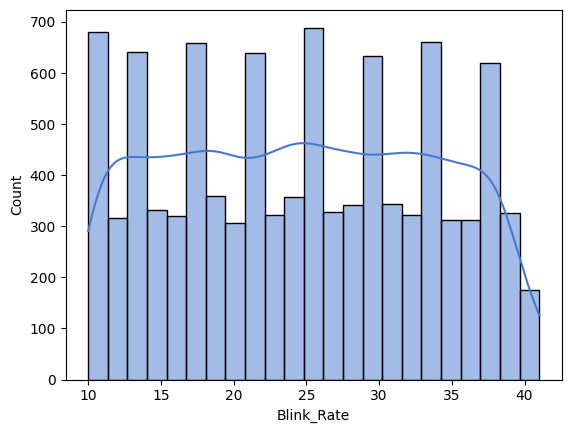

In [22]:
print("Blink_Rate description after treatment:")
sns.histplot(df['Blink_Rate'],kde=True)

- duplicate rows but with different target values

In [23]:
'''It indicates labelling inconsistency or data-collection 
error (same driver state recorded twice with conflicting ground truth).
I would drop all conflicting duplicate rows entirely 
(cannot trust either label) and log the incident for the 
engineering team. Keeping them would inject noise and hurt
ANN generalisation.'''

'It indicates labelling inconsistency or data-collection \nerror (same driver state recorded twice with conflicting ground truth).\nI would drop all conflicting duplicate rows entirely \n(cannot trust either label) and log the incident for the \nengineering team. Keeping them would inject noise and hurt\nANN generalisation.'

# Phase 3 (Eda)

- class imbalance

class imbalance


<Axes: ylabel='count'>

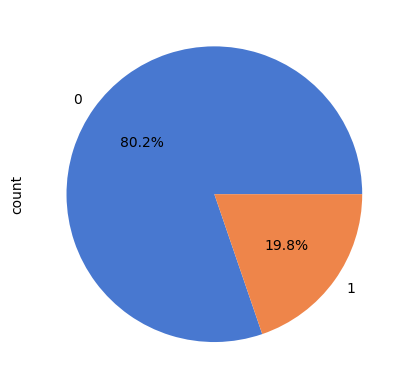

In [24]:
print('class imbalance')
df['Drowsy'].value_counts().plot(kind='pie',autopct="%1.1f%%")

In [25]:
df['Drowsy'].value_counts()

Drowsy
0    8025
1    1975
Name: count, dtype: int64

In [26]:
'''drowsiness is a rare event , most driving hours are 
alert; fatigue only appears after long shifts, 
night driving, or sleep debt. Data collection naturally 
captures far more drives.
so imbalnce in data is normal in this case.
Impact on model: the ANN will learn to predict “Alert” (0)
extremely well but will have poor recall on “Drowsy” (1). 
In safety terms this is dangerous we might miss real fatigue cases. 
Hence we will use class weights or SMOTE later.'''

'drowsiness is a rare event , most driving hours are \nalert; fatigue only appears after long shifts, \nnight driving, or sleep debt. Data collection naturally \ncaptures far more drives.\nso imbalnce in data is normal in this case.\nImpact on model: the ANN will learn to predict “Alert” (0)\nextremely well but will have poor recall on “Drowsy” (1). \nIn safety terms this is dangerous we might miss real fatigue cases. \nHence we will use class weights or SMOTE later.'

- early indicators of drowsiness

In [27]:
'''Impact on model: the ANN will learn to predict “Alert” (0) 
extremely well but will have poor recall on “Drowsy” (1). 
In safety terms this is dangerous  we might miss real fatigue cases. 
Hence we will use class weights or SMOTE later.'''

'Impact on model: the ANN will learn to predict “Alert” (0) \nextremely well but will have poor recall on “Drowsy” (1). \nIn safety terms this is dangerous  we might miss real fatigue cases. \nHence we will use class weights or SMOTE later.'

- correlation

In [28]:
df.select_dtypes(include='number').corr()

,Age,Blink_Rate,Eye_Closure_Duration,Yawning_Count,Heart_Rate,Head_Tilt_Angle,Steering_Variation,Reaction_Time,Sleep_Hours_Last_Night,Drowsy
Age,1.000000,-0.019110,-0.012824,0.008257,-0.001413,0.017579,0.005946,0.015517,0.011770,-0.001596
Blink_Rate,-0.019110,1.000000,0.007597,-0.006269,0.006290,0.003991,-0.013460,0.010151,0.013281,-0.006974
Eye_Closure_Duration,-0.012824,0.007597,1.000000,0.014214,0.012523,0.002410,-0.001166,-0.013520,-0.013311,0.004843
Yawning_Count,0.008257,-0.006269,0.014214,1.000000,-0.011724,0.010980,-0.000454,-0.001217,-0.017185,0.010536
Heart_Rate,-0.001413,0.006290,0.012523,-0.011724,1.000000,0.009600,-0.000661,-0.010948,0.024872,0.003500
Head_Tilt_Angle,0.017579,0.003991,0.002410,0.010980,0.009600,1.000000,-0.007483,-0.004655,0.007362,-0.001683
Steering_Variation,0.005946,-0.013460,-0.001166,-0.000454,-0.000661,-0.007483,1.000000,-0.012669,0.001733,-0.006402
Reaction_Time,0.015517,0.010151,-0.013520,-0.001217,-0.010948,-0.004655,-0.012669,1.000000,-0.013672,-0.005999
Sleep_Hours_Last_Night,0.011770,0.013281,-0.013311,-0.017185,0.024872,0.007362,0.001733,-0.013672,1.000000,0.009273
Drowsy,-0.001596,-0.006974,0.004843,0.010536,0.003500,-0.001683,-0.006402,-0.005999,0.009273,1.000000


<Axes: >

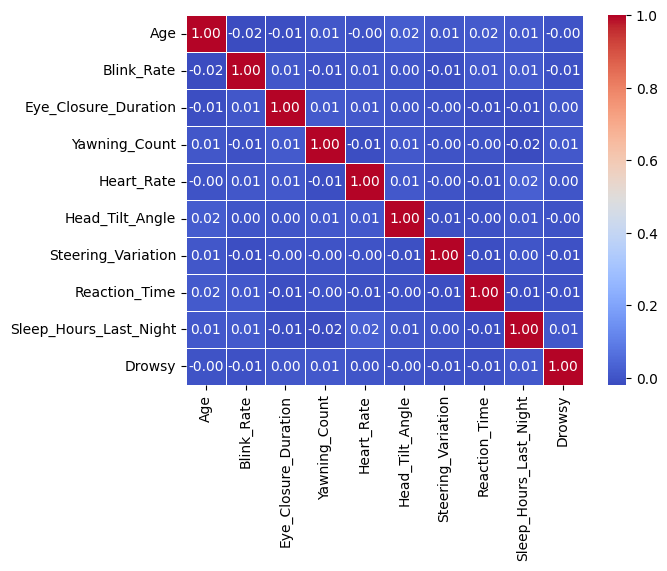

In [29]:
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

In [30]:
'''No, it is not useless. Weak linear correlation (Pearson) 
does not mean zero predictive power. Sleep hours may have a non-linear
threshold effect (e.g., <4 hours suddenly risky) or interact with age/time-of-day.
ANN hidden layers can still extract value; I would keep it and check permutation importance or 
SHAP after training.'''

'No, it is not useless. Weak linear correlation (Pearson) \ndoes not mean zero predictive power. Sleep hours may have a non-linear\nthreshold effect (e.g., <4 hours suddenly risky) or interact with age/time-of-day.\nANN hidden layers can still extract value; I would keep it and check permutation importance or \nSHAP after training.'

- eye closure duration and blink rate

In [31]:
'''when eyes stay closed longer, blink frequency drops dramatically. 
Real-world driver behaviour: the driver is slipping into micro-sleeps .
the eyes close and stay closed instead of normal quick blinks.'''

'when eyes stay closed longer, blink frequency drops dramatically. \nReal-world driver behaviour: the driver is slipping into micro-sleeps .\nthe eyes close and stay closed instead of normal quick blinks.'

- Higher reaction time and steering variation

In [32]:
'''Higher reaction time = brain processing speed slows under fatigue (microsleeps delay hazard response).
Higher steering variation = the driver makes erratic corrections or drifts because attention lapses; 
the car wanders in the lane. Both are classic late-stage fatigue signs visible to vehicle sensors.'''

'Higher reaction time = brain processing speed slows under fatigue (microsleeps delay hazard response).\nHigher steering variation = the driver makes erratic corrections or drifts because attention lapses; \nthe car wanders in the lane. Both are classic late-stage fatigue signs visible to vehicle sensors.'

# phase 4 (Data preprocessing)

- data splitting and defining feature group

In [33]:
X=df.drop('Drowsy',axis=1)
y=df['Drowsy'].astype(int)

In [34]:
X.columns

Index(['Age', 'Gender', 'Blink_Rate', 'Eye_Closure_Duration', 'Yawning_Count',
       'Heart_Rate', 'Head_Tilt_Angle', 'Steering_Variation', 'Reaction_Time',
       'Sleep_Hours_Last_Night'],
      dtype='object')

In [35]:
num_cols = X.select_dtypes(include='number').columns
cat_cols= X.select_dtypes(include='object').columns

- preprocessing pipelines

In [36]:
numeric_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

In [37]:
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

In [38]:
preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

In [39]:
'''I will build a full scikit-learn Pipeline containing: 
SimpleImputer → OneHotEncoder for categorical and, KNNImputer → StandardScaler for numerical data . 
Fit only on training data, save the entire pipeline object (joblib).
this will  ensure that future incoming data is processed consistently'''

'I will build a full scikit-learn Pipeline containing: \nSimpleImputer → OneHotEncoder for categorical and, KNNImputer → StandardScaler for numerical data . \nFit only on training data, save the entire pipeline object (joblib).\nthis will  ensure that future incoming data is processed consistently'

In [40]:
'''Using OneHotEncoder(handle_unknown='ignore') in the pipeline: 
any new category (“Other”) will produce a row of zeros for all known 
categories (treated as unseen). This is safe and does not crash the 
model. I can monitor the frequency of “unknown” and retrain periodically if needed.'''

"Using OneHotEncoder(handle_unknown='ignore') in the pipeline: \nany new category (“Other”) will produce a row of zeros for all known \ncategories (treated as unseen). This is safe and does not crash the \nmodel. I can monitor the frequency of “unknown” and retrain periodically if needed."

# phase 5(Insights and reasoning)

In [41]:
'''The three most critical features (based on domain logic + typical EDA patterns in such datasets):
Eye_Closure_Duration – longest direct physiological marker; prolonged closure is the earliest and strongest sign of micro-sleep.
Reaction_Time – captures cognitive slowing; drowsy drivers consistently show higher values (as noted in the observed pattern).
Steering_Variation – behavioural indicator of loss of vehicle control; erratic steering appears when attention lapses.

Justification: These three combine camera-based physiology and vehicle dynamics .
They are real-time, low-latency, and have proven high predictive power in fatigue literature. 
ANN will learn non-linear interactions among them far better than any rule-based threshold. 
Sleep_Hours and Yawning_Count are useful supporting features but these three are the core trio for reliable drowsiness detection.'''

'The three most critical features (based on domain logic + typical EDA patterns in such datasets):\nEye_Closure_Duration – longest direct physiological marker; prolonged closure is the earliest and strongest sign of micro-sleep.\nReaction_Time – captures cognitive slowing; drowsy drivers consistently show higher values (as noted in the observed pattern).\nSteering_Variation – behavioural indicator of loss of vehicle control; erratic steering appears when attention lapses.\n\nJustification: These three combine camera-based physiology and vehicle dynamics .\nThey are real-time, low-latency, and have proven high predictive power in fatigue literature. \nANN will learn non-linear interactions among them far better than any rule-based threshold. \nSleep_Hours and Yawning_Count are useful supporting features but these three are the core trio for reliable drowsiness detection.'

# Model Development

In [42]:
# Step 1: split test first
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# Step 2: split train/val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, stratify=y_temp, random_state=42
)

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X_temp, y_temp, test_size=0.15, stratify=y_temp, random_state=42
)

In [44]:
# Transform
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)
X_val_prep=preprocessor.transform(X_val)

In [45]:
def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        # Convert to float
        y_true = tf.cast(y_true, tf.float32)
        
        # Clip predictions to prevent log(0)
        epsilon = K.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        # Compute cross entropy
        cross_entropy = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)

        # Compute focal weight
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_weight = alpha * tf.pow((1 - p_t), gamma)

        # Final loss
        loss = focal_weight * cross_entropy
        return tf.reduce_mean(loss)

    return loss

In [46]:
def build_drowsiness_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.30),
        Dense(64, activation='relu'),
        Dropout(0.20),
        Dense(32, activation='relu'),
        Dropout(0.10),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        # loss=focal_loss(alpha=0.25, gamma=2),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )
    return model

In [47]:
model = build_drowsiness_model(X_train_prep.shape[1])

In [48]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0,1]),
    y=y_train
)

In [49]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=10,
    mode='max',
    restore_best_weights=True
)

history = model.fit(
    X_train_prep, y_train,
    # validation_data=(X_val_prep, y_val),
    validation_split=0.15,
    epochs=500,
    batch_size=32,
    callbacks=[early_stop],
    class_weight = {0: weights[0], 1: weights[1]}  # adjust based on imbalance
)

Epoch 1/500
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5037 - auc: 0.4943 - loss: 0.7046 - recall: 0.4858 - val_accuracy: 0.6485 - val_auc: 0.5046 - val_loss: 0.6783 - val_recall: 0.3010
Epoch 2/500
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5077 - auc: 0.5105 - loss: 0.6989 - recall: 0.5093 - val_accuracy: 0.4207 - val_auc: 0.4760 - val_loss: 0.7076 - val_recall: 0.5765
Epoch 3/500
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4970 - auc: 0.5257 - loss: 0.6968 - recall: 0.5605 - val_accuracy: 0.5258 - val_auc: 0.4834 - val_loss: 0.6926 - val_recall: 0.4388
Epoch 4/500
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5097 - auc: 0.5226 - loss: 0.6967 - recall: 0.5223 - val_accuracy: 0.4686 - val_auc: 0.4889 - val_loss: 0.7002 - val_recall: 0.5153
Epoch 5/500
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4879 - auc: 0.5393 - loss: 0.6946 - recall: 0.5906 - val_accuracy: 0.5397 - val_auc: 0.5023 - val_loss: 0.6897 - val_recall: 0.4439
Epoch

In [60]:
threshold = 0.40
y_pred_prob = model.predict(X_test_prep).ravel()
y_pred = (y_pred_prob >= threshold).astype(int)

# --- METRICS ---
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

# --- CONFUSION MATRIX ---
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# --- CLASSIFICATION REPORT ---
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))



40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy : 0.28941176470588237
Precision: 0.19722222222222222
Recall   : 0.8452380952380952
F1 Score : 0.31981981981981983
ROC-AUC  : 0.5015748886716629

Confusion Matrix:
 [[156 867]
 [ 39 213]]

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.15      0.26      1023
           1       0.20      0.85      0.32       252

    accuracy                           0.29      1275
   macro avg       0.50      0.50      0.29      1275
weighted avg       0.68      0.29      0.27      1275



In [51]:
def plot_precision_recall_vs_threshold(y_test, y_pred_prob):
    thresholds = np.linspace(0, 1, 100)

    precisions = []
    recalls = []
    accuracies = []
    f1s = []

    for thresh in thresholds:
        y_pred = (y_pred_prob >= thresh).astype(int)

        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        precisions.append(precision)
        recalls.append(recall)
        accuracies.append(acc)
        f1s.append(f1)

    # Plot
    plt.figure()
    plt.plot(thresholds, precisions, label='Precision')
    plt.plot(thresholds, recalls, label='Recall')
    plt.plot(thresholds, f1s, label='F1 Score') 
    plt.plot(thresholds, accuracies, label='Accuracy', linestyle='--')

    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Metrics vs Threshold')
    plt.legend()
    plt.grid()
    plt.show()

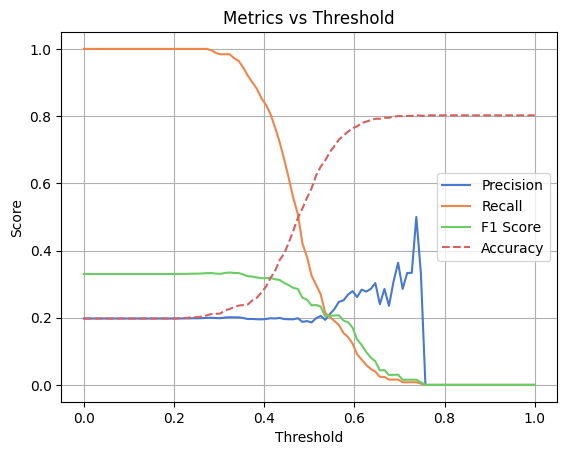

In [52]:
plot_precision_recall_vs_threshold(y_test,y_pred_prob)

In [53]:
from sklearn.metrics import precision_score, recall_score

best_t = 0
best_recall = 0
thresholds = np.linspace(0, 1, 200)
for t in thresholds:
    y_pred = (y_pred_prob >= t).astype(int)

    p = precision_score(y_test, y_pred, zero_division=0)
    r = recall_score(y_test, y_pred)

    if r > 0.9 and p >= 0.15:  # set your tolerance
        best_recall = r
        best_t = t

print(best_t, best_recall)

0.37185929648241206 0.9007936507936508


In [54]:
def plot_loss_curve(history, test_loss=None):
    train_loss = history.history['loss']
    val_loss = history.history.get('val_loss')

    plt.figure()
    plt.plot(train_loss, label='Train Loss')

    # if val_loss:
    #     plt.plot(val_loss, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.legend()
    plt.grid()
    plt.show()

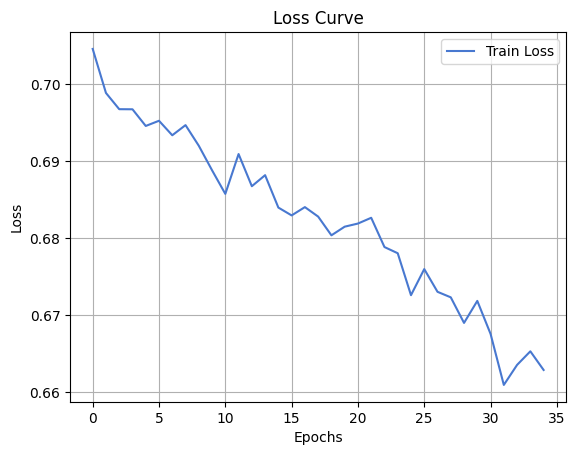

In [55]:
plot_loss_curve(history)

In [56]:
model.save("model.keras") 

In [57]:
import pickle
# with open("Drowsiness.pkl", "wb") as f:
#     pickle.dump(model, f)
with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

In [58]:
import keras
print(keras.__version__)

3.12.1
